# Lung X-Ray Classification Using Deep Learning

This notebook explores convolutional neural networks and transfer learning for classifying chest X-ray images into **Normal**, **Opacity**, and **Pneumonia** categories.

## Project Overview

The workflow covers data preparation, model development, transfer-learning experiments, training, and final evaluation. Custom CNN architectures are compared with established pretrained models to assess predictive performance and parameter efficiency.

## Dataset Setup

The following cell can be used in Google Colab to extract the uploaded dataset. When running locally, update the dataset path as needed.

In [1]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
   creating: dataset/Normal/
  inflating: dataset/Normal/1.jpg    
  inflating: dataset/Normal/10.jpg   
  inflating: dataset/Normal/100.jpg  
  inflating: dataset/Normal/1000.jpg  
  inflating: dataset/Normal/1001.jpg  
  inflating: dataset/Normal/1002.jpg  
  inflating: dataset/Normal/1003.jpg  
  inflating: dataset/Normal/1004.jpg  
  inflating: dataset/Normal/1005.jpg  
  inflating: dataset/Normal/1006.jpg  
  inflating: dataset/Normal/1007.jpg  
  inflating: dataset/Normal/1008.jpg  
  inflating: dataset/Normal/1009.jpg  
  inflating: dataset/Normal/101.jpg  
  inflating: dataset/Normal/1010.jpg  
  inflating: dataset/Normal/1011.jpg  
  inflating: dataset/Normal/1012.jpg  
  inflating: dataset/Normal/1013.jpg  
  inflating: dataset/Normal/1014.jpg  
  inflating: dataset/Normal/1015.jpg  
  inflating: dataset/Normal/1016.jpg  
  inflating: dataset/Normal/1017.jpg  
  inflating: dataset/Normal/1018.jpg  
  inflating: dataset/Normal/1019.j

## Imports

Import the libraries required for data processing, model development, training, evaluation, and visualisation.

In [2]:
%matplotlib inline
from __future__ import unicode_literals, print_function, division

import os
import copy
import math
import time
import random
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# set random seed
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 1. Data Preparation

This section prepares the dataset for experimentation. It defines the train, validation, and test splits, constructs the data loaders, and applies the preprocessing and augmentation steps used during model training and evaluation.

In [3]:
#Experiment settings
data_dir = "dataset"
image_size = 224
batch_size = 32
num_workers = 2
num_classes = 3
val_ratio = 0.15
test_ratio = 0.15
num_epochs = 15
early_stopping_patience = 4

In [4]:
#inspect dataset before preprocessing
base_dataset = datasets.ImageFolder(root=data_dir)

print("Classes:", base_dataset.classes)
print("Class to index:", base_dataset.class_to_idx)
print("Total images:", len(base_dataset))

all_labels = [label for _, label in base_dataset.samples]
class_counts = Counter(all_labels)

print("Class counts:")
for class_name, class_idx in base_dataset.class_to_idx.items():
    print(f"{class_name}: {class_counts[class_idx]}")

Classes: ['Normal', 'Opacity', 'Pneumonia']
Class to index: {'Normal': 0, 'Opacity': 1, 'Pneumonia': 2}
Total images: 3475
Class counts:
Normal: 1250
Opacity: 1125
Pneumonia: 1100


In [5]:
#train validation test split
indices = np.arange(len(base_dataset))
labels = np.array([label for _, label in base_dataset.samples])

train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices,
    labels,
    test_size=val_ratio + test_ratio,
    stratify=labels,
    random_state=seed
)

relative_test_ratio = test_ratio / (val_ratio + test_ratio)

val_idx, test_idx, val_labels, test_labels = train_test_split(
    temp_idx,
    temp_labels,
    test_size=relative_test_ratio,
    stratify=temp_labels,
    random_state=seed
)

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 2432
Validation size: 521
Test size: 522


In [6]:
#preprocessing and augmentation
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [7]:
#datasets and dataloaders
train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(root=data_dir, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(eval_dataset_full, val_idx)
test_dataset = Subset(eval_dataset_full, test_idx)

train_targets = labels[train_idx]
train_class_counts = Counter(train_targets)

class_weights = {
    class_idx: len(train_targets) / count
    for class_idx, count in train_class_counts.items()
}

sample_weights = [class_weights[labels[i]] for i in train_idx]
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

loss_class_weights = torch.tensor(
    [class_weights[i] for i in range(num_classes)],
    dtype=torch.float32,
    device=device
)

print("Loss class weights:", loss_class_weights)

Loss class weights: tensor([2.7794, 3.0902, 3.1584], device='cuda:0')


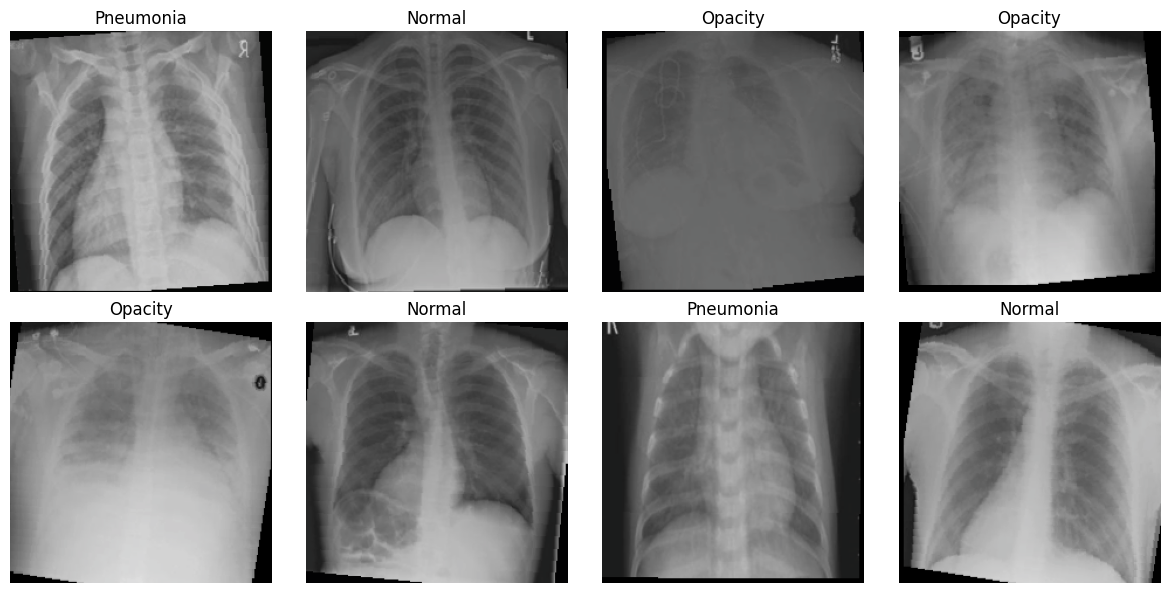

In [8]:
#visualize preprocessed samples
class_names = base_dataset.classes

images, targets = next(iter(train_loader))
images = images[:8].cpu()
targets = targets[:8].cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[targets[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

Classes: ['Normal', 'Opacity', 'Pneumonia']
Class to index: {'Normal': 0, 'Opacity': 1, 'Pneumonia': 2}
Total images: 3475

Class counts:
Normal: 1250
Opacity: 1125
Pneumonia: 1100


,class_name,num_images
0,Normal,1250
1,Opacity,1125
2,Pneumonia,1100


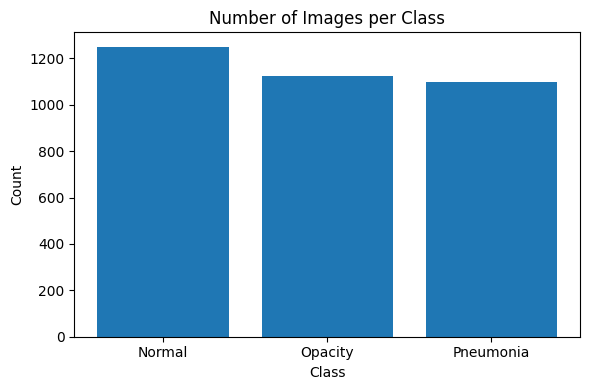

In [9]:

# inspect image dataset structure
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Image dataset folder not found: {data_dir}")

base_dataset = datasets.ImageFolder(root=data_dir)

print("Classes:", base_dataset.classes)
print("Class to index:", base_dataset.class_to_idx)
print("Total images:", len(base_dataset))

all_labels = [label for _, label in base_dataset.samples]
class_counts = Counter(all_labels)

print("\nClass counts:")
for class_name, class_idx in base_dataset.class_to_idx.items():
    print(f"{class_name}: {class_counts[class_idx]}")

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
rows = []

for class_name in base_dataset.classes:
    class_path = os.path.join(data_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if os.path.splitext(f)[1].lower() in valid_extensions
    ]
    rows.append({
        "class_name": class_name,
        "num_images": len(image_files)
    })

dataset_summary_df = pd.DataFrame(rows)
display(dataset_summary_df)

plt.figure(figsize=(6, 4))
plt.bar(dataset_summary_df["class_name"], dataset_summary_df["num_images"])
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2. Model Development and Training

This section develops and trains the models used in the comparison. It includes a custom CNN trained from scratch alongside established CNN architectures evaluated using transfer-learning strategies such as feature extraction and fine-tuning. Training loss and accuracy are tracked across epochs to compare model behaviour and performance.

## Custom CNN

The following model provides a lightweight custom CNN baseline for comparison with the deeper architecture and pretrained models.

In [10]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [11]:
class OriginalCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(OriginalCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (image_size // 4) * (image_size // 4), num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

original_model = OriginalCNN(num_classes=num_classes).to(device)
print(original_model)
print("Original CNN trainable parameters:", count_parameters(original_model))

OriginalCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=3, bias=True)
  )
)
Original CNN trainable parameters: 306147


In [12]:
# Improved CNN revised
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (image_size // 8) * (image_size // 8), 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

improved_model = ImprovedCNN(num_classes=num_classes).to(device)
print(improved_model)
print("Improved CNN trainable parameters:", count_parameters(improved_model))

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

## Pretrained CNN Architectures

The following experiments evaluate established convolutional neural network architectures on the same classification task using transfer learning and fine-tuning strategies.

In [13]:
selected_model_names = [
    "alexnet",
    "vgg16",
    "googlenet",
    "resnet18",
    "densenet121",
    "efficientnet_b0",
    "regnet_y_400mf",
    "convnext_tiny"
]

selected_strategies = {
    "alexnet": ["feature_extract", "fine_tune"],
    "vgg16": ["feature_extract"],
    "googlenet": ["feature_extract", "fine_tune"],
    "resnet18": ["feature_extract", "fine_tune", "from_scratch"],
    "densenet121": ["feature_extract", "fine_tune"],
    "efficientnet_b0": ["feature_extract", "fine_tune"],
    "regnet_y_400mf": ["feature_extract"],
    "convnext_tiny": ["feature_extract"]
}

In [14]:
#Existing CNN helper functions
def get_weights_enum(model_name):
    if model_name == "alexnet":
        return models.AlexNet_Weights.DEFAULT
    if model_name == "vgg16":
        return models.VGG16_Weights.DEFAULT
    if model_name == "googlenet":
        return models.GoogLeNet_Weights.DEFAULT
    if model_name == "resnet18":
        return models.ResNet18_Weights.DEFAULT
    if model_name == "densenet121":
        return models.DenseNet121_Weights.DEFAULT
    if model_name == "efficientnet_b0":
        return models.EfficientNet_B0_Weights.DEFAULT
    if model_name == "regnet_y_400mf":
        return models.RegNet_Y_400MF_Weights.DEFAULT
    if model_name == "convnext_tiny":
        return models.ConvNeXt_Tiny_Weights.DEFAULT
    raise ValueError(f"Unknown model name: {model_name}")


def replace_classifier(model, model_name, num_classes):
    if model_name == "alexnet":
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif model_name == "vgg16":
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    elif model_name == "googlenet":
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
        if hasattr(model, "aux1") and model.aux1 is not None:
            aux1_in = model.aux1.fc2.in_features
            model.aux1.fc2 = nn.Linear(aux1_in, num_classes)
        if hasattr(model, "aux2") and model.aux2 is not None:
            aux2_in = model.aux2.fc2.in_features
            model.aux2.fc2 = nn.Linear(aux2_in, num_classes)

    elif model_name == "resnet18":
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "densenet121":
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "regnet_y_400mf":
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "convnext_tiny":
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {model_name}")

    return model


def freeze_all_except_classifier(model, model_name):
    for param in model.parameters():
        param.requires_grad = False

    if model_name in ["alexnet", "vgg16"]:
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "googlenet":
        for param in model.fc.parameters():
            param.requires_grad = True
        if hasattr(model, "aux1") and model.aux1 is not None:
            for param in model.aux1.parameters():
                param.requires_grad = True
        if hasattr(model, "aux2") and model.aux2 is not None:
            for param in model.aux2.parameters():
                param.requires_grad = True

    elif model_name in ["resnet18", "regnet_y_400mf"]:
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "densenet121":
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "efficientnet_b0":
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "convnext_tiny":
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model


def unfreeze_last_block_for_finetune(model, model_name):
    for param in model.parameters():
        param.requires_grad = False

    if model_name == "alexnet":
        for param in model.features[8:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "vgg16":
        for param in model.features[24:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "googlenet":
        for param in model.inception5a.parameters():
            param.requires_grad = True
        for param in model.inception5b.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True
        if hasattr(model, "aux1") and model.aux1 is not None:
            for param in model.aux1.parameters():
                param.requires_grad = True
        if hasattr(model, "aux2") and model.aux2 is not None:
            for param in model.aux2.parameters():
                param.requires_grad = True

    elif model_name == "resnet18":
        for param in model.layer4.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "densenet121":
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "efficientnet_b0":
        for param in model.features[6:].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    elif model_name == "regnet_y_400mf":
        for param in model.trunk_output[-1].parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    elif model_name == "convnext_tiny":
        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model


def create_model(model_name, strategy, num_classes):
    if strategy == "from_scratch":
        if model_name == "googlenet":
            model = getattr(models, model_name)(weights=None, aux_logits=True)
        else:
            model = getattr(models, model_name)(weights=None)
    else:
        weights = get_weights_enum(model_name)
        if model_name == "googlenet":
            model = getattr(models, model_name)(weights=weights, aux_logits=True)
        else:
            model = getattr(models, model_name)(weights=weights)

    model = replace_classifier(model, model_name, num_classes)

    if strategy == "feature_extract":
        model = freeze_all_except_classifier(model, model_name)
    elif strategy == "fine_tune":
        model = unfreeze_last_block_for_finetune(model, model_name)
    elif strategy == "from_scratch":
        for param in model.parameters():
            param.requires_grad = True
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return model.to(device)

In [15]:
#Define the necessary training components
def get_criterion():
    return nn.CrossEntropyLoss(weight=loss_class_weights, label_smoothing=0.05)


def get_optimizer(model, strategy, model_name):
    params_to_update = [p for p in model.parameters() if p.requires_grad]

    if strategy == "feature_extract":
        lr = 1e-3
    elif strategy == "fine_tune":
        lr = 3e-4
    else:
        lr = 1e-3 if model_name == "resnet18" else 5e-4

    return optim.Adam(params_to_update, lr=lr, weight_decay=1e-4)


def get_scheduler(optimizer):
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

In [16]:
#Evaluation helper used during training
def get_logits_from_output(output):
    if isinstance(output, tuple):
        return output[0]
    return output


def evaluate_model(model, dataloader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            logits = get_logits_from_output(outputs)
            loss = criterion(logits, targets)

            preds = torch.argmax(logits, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_precision = precision_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_recall = recall_score(all_targets, all_preds, average="macro", zero_division=0)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    metrics = {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "precision_macro": epoch_precision,
        "recall_macro": epoch_recall,
        "f1_macro": epoch_f1
    }

    return metrics, np.array(all_targets), np.array(all_preds)

In [17]:
#Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, model_name, strategy, num_epochs=15):
    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()

        running_loss = 0.0
        all_preds = []
        all_targets = []

        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if model_name == "googlenet" and strategy != "feature_extract" and model.training:
                logits, aux2, aux1 = outputs
                loss_main = criterion(logits, targets)
                loss_aux1 = criterion(aux1, targets)
                loss_aux2 = criterion(aux2, targets)
                loss = loss_main + 0.3 * loss_aux1 + 0.3 * loss_aux2
            else:
                logits = get_logits_from_output(outputs)
                loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            preds = torch.argmax(logits, dim=1)

            running_loss += loss.item() * images.size(0)
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_targets, all_preds)
        train_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

        val_metrics, _, _ = evaluate_model(model, val_loader, criterion)
        scheduler.step(val_metrics["loss"])

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1_macro"])

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1_macro']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    return model, history

In [18]:
#Plot loss and accuracy for each training procedure
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

Epoch 01/15 | Train Loss: 0.6644 | Train Acc: 0.7500 | Train F1: 0.7485 | Val Loss: 0.5192 | Val Acc: 0.8369 | Val F1: 0.8369
Epoch 02/15 | Train Loss: 0.5577 | Train Acc: 0.8039 | Train F1: 0.8024 | Val Loss: 0.4976 | Val Acc: 0.8522 | Val F1: 0.8532
Epoch 03/15 | Train Loss: 0.5023 | Train Acc: 0.8392 | Train F1: 0.8376 | Val Loss: 0.4698 | Val Acc: 0.8503 | Val F1: 0.8510
Epoch 04/15 | Train Loss: 0.4647 | Train Acc: 0.8590 | Train F1: 0.8551 | Val Loss: 0.4625 | Val Acc: 0.8656 | Val F1: 0.8672
Epoch 05/15 | Train Loss: 0.4801 | Train Acc: 0.8433 | Train F1: 0.8393 | Val Loss: 0.4542 | Val Acc: 0.8599 | Val F1: 0.8614
Epoch 06/15 | Train Loss: 0.4524 | Train Acc: 0.8590 | Train F1: 0.8586 | Val Loss: 0.4364 | Val Acc: 0.8772 | Val F1: 0.8794
Epoch 07/15 | Train Loss: 0.4564 | Train Acc: 0.8532 | Train F1: 0.8515 | Val Loss: 0.4567 | Val Acc: 0.8714 | Val F1: 0.8740
Epoch 08/15 | Train Loss: 0.4635 | Train Acc: 0.8540 | Train F1: 0.8540 | Val Loss: 0.4831 | Val Acc: 0.8426 | Val F1:

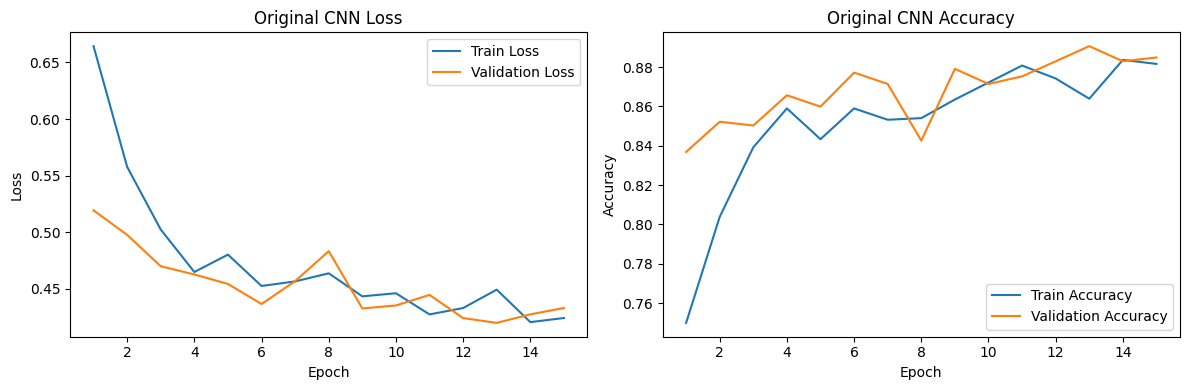

Epoch 01/15 | Train Loss: 1.0939 | Train Acc: 0.5107 | Train F1: 0.5094 | Val Loss: 0.6540 | Val Acc: 0.7601 | Val F1: 0.7573
Epoch 02/15 | Train Loss: 0.6694 | Train Acc: 0.7426 | Train F1: 0.7395 | Val Loss: 0.5258 | Val Acc: 0.8273 | Val F1: 0.8267
Epoch 03/15 | Train Loss: 0.6405 | Train Acc: 0.7586 | Train F1: 0.7566 | Val Loss: 0.5146 | Val Acc: 0.8407 | Val F1: 0.8398
Epoch 04/15 | Train Loss: 0.5517 | Train Acc: 0.8018 | Train F1: 0.8010 | Val Loss: 0.4838 | Val Acc: 0.8503 | Val F1: 0.8504
Epoch 05/15 | Train Loss: 0.5614 | Train Acc: 0.7993 | Train F1: 0.7964 | Val Loss: 0.5009 | Val Acc: 0.8541 | Val F1: 0.8572
Epoch 06/15 | Train Loss: 0.5411 | Train Acc: 0.8162 | Train F1: 0.8166 | Val Loss: 0.4638 | Val Acc: 0.8407 | Val F1: 0.8415
Epoch 07/15 | Train Loss: 0.5159 | Train Acc: 0.8339 | Train F1: 0.8326 | Val Loss: 0.4382 | Val Acc: 0.8618 | Val F1: 0.8639
Epoch 08/15 | Train Loss: 0.5128 | Train Acc: 0.8413 | Train F1: 0.8410 | Val Loss: 0.4297 | Val Acc: 0.8887 | Val F1:

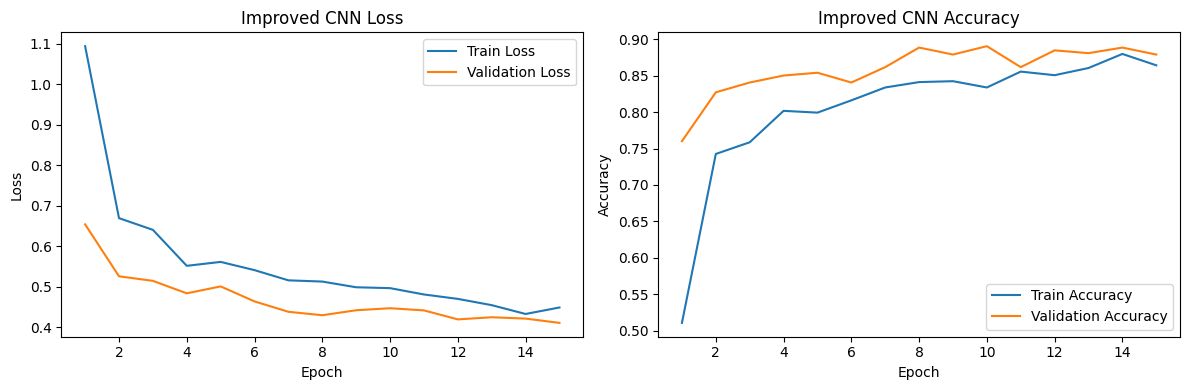

In [19]:
# train original cnn
original_criterion = get_criterion()
original_optimizer = get_optimizer(original_model, strategy="from_scratch", model_name="original")
original_scheduler = get_scheduler(original_optimizer)

original_model, original_history = train_model(
    model=original_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=original_criterion,
    optimizer=original_optimizer,
    scheduler=original_scheduler,
    model_name="original",
    strategy="from_scratch",
    num_epochs=num_epochs
)

plot_history(original_history, "Original CNN")


# train improved cnn
improved_criterion = get_criterion()
improved_optimizer = get_optimizer(improved_model, strategy="from_scratch", model_name="improved")
improved_scheduler = get_scheduler(improved_optimizer)

improved_model, improved_history = train_model(
    model=improved_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=improved_criterion,
    optimizer=improved_optimizer,
    scheduler=improved_scheduler,
    model_name="improved",
    strategy="from_scratch",
    num_epochs=num_epochs
)

plot_history(improved_history, "Improved CNN")

In [20]:
trained_models = {}
histories = {}
validation_results = []

# add original cnn
original_val_metrics, _, _ = evaluate_model(original_model, val_loader, original_criterion)
trained_models["original_from_scratch"] = original_model
histories["original_from_scratch"] = original_history

validation_results.append({
    "model": "original",
    "strategy": "from_scratch",
    "trainable_params": count_parameters(original_model),
    "train_loss": original_history["train_loss"][-1],
    "train_accuracy": original_history["train_acc"][-1],
    "train_f1_macro": original_history["train_f1"][-1],
    "val_loss": original_val_metrics["loss"],
    "val_accuracy": original_val_metrics["accuracy"],
    "val_precision_macro": original_val_metrics["precision_macro"],
    "val_recall_macro": original_val_metrics["recall_macro"],
    "val_f1_macro": original_val_metrics["f1_macro"]
})

# add improved cnn
improved_val_metrics, _, _ = evaluate_model(improved_model, val_loader, improved_criterion)
trained_models["improved_from_scratch"] = improved_model
histories["improved_from_scratch"] = improved_history

validation_results.append({
    "model": "improved",
    "strategy": "from_scratch",
    "trainable_params": count_parameters(improved_model),
    "train_loss": improved_history["train_loss"][-1],
    "train_accuracy": improved_history["train_acc"][-1],
    "train_f1_macro": improved_history["train_f1"][-1],
    "val_loss": improved_val_metrics["loss"],
    "val_accuracy": improved_val_metrics["accuracy"],
    "val_precision_macro": improved_val_metrics["precision_macro"],
    "val_recall_macro": improved_val_metrics["recall_macro"],
    "val_f1_macro": improved_val_metrics["f1_macro"]
})

In [ ]:
results_df = pd.DataFrame(validation_results)
results_df = results_df.sort_values(by=["val_f1_macro", "val_accuracy"], ascending=False).reset_index(drop=True)
results_df

,model,strategy,trainable_params,train_loss,train_accuracy,train_f1_macro,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro
0,improved,from_scratch,12934259,0.459055,0.868832,0.869705,0.400759,0.896353,0.901788,0.896336,0.898196
1,original,from_scratch,306147,0.433164,0.872122,0.873120,0.429460,0.871401,0.875202,0.873969,0.873795



Training alexnet with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 158MB/s]


Epoch 01/15 | Train Loss: 0.7117 | Train Acc: 0.7825 | Train F1: 0.7830 | Val Loss: 0.5463 | Val Acc: 0.8349 | Val F1: 0.8349
Epoch 02/15 | Train Loss: 0.4672 | Train Acc: 0.8561 | Train F1: 0.8574 | Val Loss: 0.3629 | Val Acc: 0.9251 | Val F1: 0.9261
Epoch 03/15 | Train Loss: 0.4273 | Train Acc: 0.8799 | Train F1: 0.8797 | Val Loss: 0.4127 | Val Acc: 0.8887 | Val F1: 0.8895
Epoch 04/15 | Train Loss: 0.4076 | Train Acc: 0.8894 | Train F1: 0.8888 | Val Loss: 0.3554 | Val Acc: 0.9309 | Val F1: 0.9318
Epoch 05/15 | Train Loss: 0.4124 | Train Acc: 0.8849 | Train F1: 0.8851 | Val Loss: 0.3627 | Val Acc: 0.9021 | Val F1: 0.9043
Epoch 06/15 | Train Loss: 0.3994 | Train Acc: 0.8984 | Train F1: 0.8994 | Val Loss: 0.3754 | Val Acc: 0.8964 | Val F1: 0.8975
Epoch 07/15 | Train Loss: 0.4189 | Train Acc: 0.8964 | Train F1: 0.8988 | Val Loss: 0.3566 | Val Acc: 0.9155 | Val F1: 0.9177
Epoch 08/15 | Train Loss: 0.3653 | Train Acc: 0.9075 | Train F1: 0.9074 | Val Loss: 0.3497 | Val Acc: 0.9155 | Val F1:

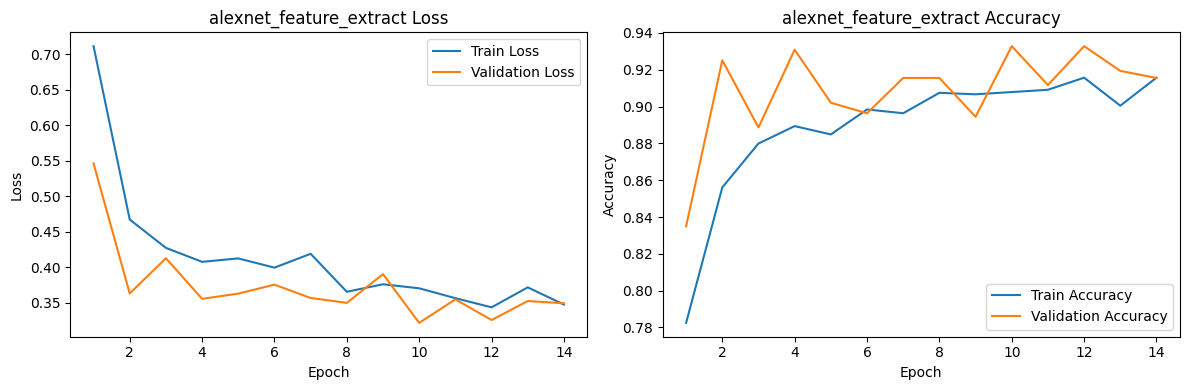


Training alexnet with strategy: fine_tune
Epoch 01/15 | Train Loss: 0.5485 | Train Acc: 0.8269 | Train F1: 0.8263 | Val Loss: 0.4083 | Val Acc: 0.8848 | Val F1: 0.8873
Epoch 02/15 | Train Loss: 0.3918 | Train Acc: 0.9005 | Train F1: 0.8995 | Val Loss: 0.4222 | Val Acc: 0.8829 | Val F1: 0.8857
Epoch 03/15 | Train Loss: 0.3589 | Train Acc: 0.9128 | Train F1: 0.9138 | Val Loss: 0.3617 | Val Acc: 0.9098 | Val F1: 0.9120
Epoch 04/15 | Train Loss: 0.3374 | Train Acc: 0.9280 | Train F1: 0.9282 | Val Loss: 0.3252 | Val Acc: 0.9347 | Val F1: 0.9362
Epoch 05/15 | Train Loss: 0.3319 | Train Acc: 0.9289 | Train F1: 0.9293 | Val Loss: 0.3347 | Val Acc: 0.9271 | Val F1: 0.9286
Epoch 06/15 | Train Loss: 0.3271 | Train Acc: 0.9301 | Train F1: 0.9299 | Val Loss: 0.3856 | Val Acc: 0.9002 | Val F1: 0.9028
Epoch 07/15 | Train Loss: 0.3173 | Train Acc: 0.9346 | Train F1: 0.9353 | Val Loss: 0.3295 | Val Acc: 0.9271 | Val F1: 0.9289
Epoch 08/15 | Train Loss: 0.2755 | Train Acc: 0.9548 | Train F1: 0.9546 | V

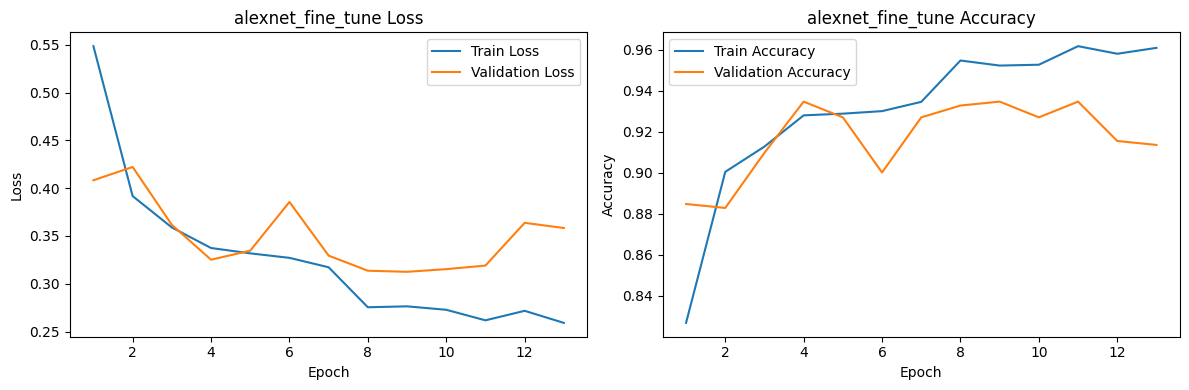


Training vgg16 with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 126MB/s]


Epoch 01/15 | Train Loss: 0.8662 | Train Acc: 0.7401 | Train F1: 0.7401 | Val Loss: 0.5179 | Val Acc: 0.8522 | Val F1: 0.8566
Epoch 02/15 | Train Loss: 0.4552 | Train Acc: 0.8746 | Train F1: 0.8740 | Val Loss: 0.4527 | Val Acc: 0.8868 | Val F1: 0.8876
Epoch 03/15 | Train Loss: 0.4667 | Train Acc: 0.8738 | Train F1: 0.8716 | Val Loss: 0.4072 | Val Acc: 0.8829 | Val F1: 0.8860
Epoch 04/15 | Train Loss: 0.4529 | Train Acc: 0.8832 | Train F1: 0.8810 | Val Loss: 0.5412 | Val Acc: 0.8733 | Val F1: 0.8769
Epoch 05/15 | Train Loss: 0.4446 | Train Acc: 0.8779 | Train F1: 0.8779 | Val Loss: 0.3997 | Val Acc: 0.9040 | Val F1: 0.9062
Epoch 06/15 | Train Loss: 0.4612 | Train Acc: 0.8647 | Train F1: 0.8653 | Val Loss: 0.3842 | Val Acc: 0.9136 | Val F1: 0.9154
Epoch 07/15 | Train Loss: 0.4810 | Train Acc: 0.8705 | Train F1: 0.8710 | Val Loss: 0.3476 | Val Acc: 0.9271 | Val F1: 0.9284
Epoch 08/15 | Train Loss: 0.4884 | Train Acc: 0.8639 | Train F1: 0.8661 | Val Loss: 0.3843 | Val Acc: 0.9079 | Val F1:

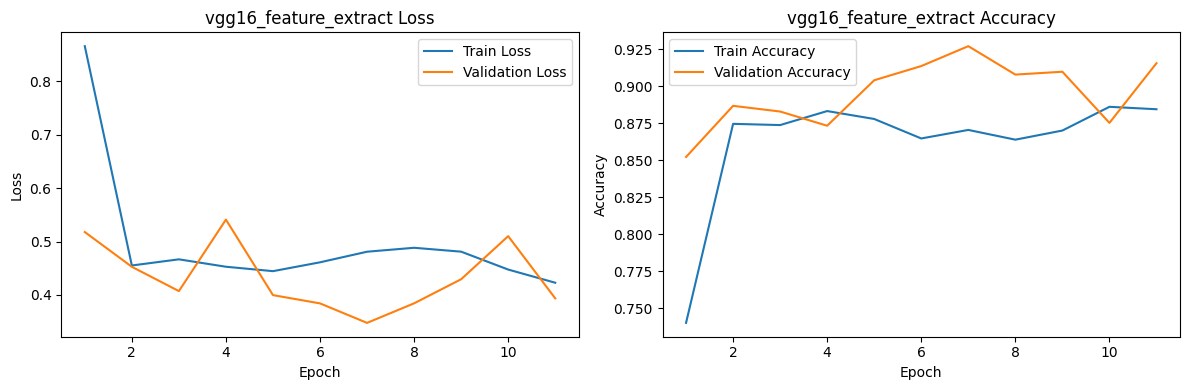


Training googlenet with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 72.7MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 01/15 | Train Loss: 0.7981 | Train Acc: 0.7027 | Train F1: 0.6967 | Val Loss: 0.6127 | Val Acc: 0.8253 | Val F1: 0.8263
Epoch 02/15 | Train Loss: 0.5951 | Train Acc: 0.8162 | Train F1: 0.8131 | Val Loss: 0.5251 | Val Acc: 0.8541 | Val F1: 0.8561
Epoch 03/15 | Train Loss: 0.5554 | Train Acc: 0.8215 | Train F1: 0.8197 | Val Loss: 0.5180 | Val Acc: 0.8311 | Val F1: 0.8278
Epoch 04/15 | Train Loss: 0.5387 | Train Acc: 0.8261 | Train F1: 0.8228 | Val Loss: 0.4993 | Val Acc: 0.8503 | Val F1: 0.8532
Epoch 05/15 | Train Loss: 0.5171 | Train Acc: 0.8322 | Train F1: 0.8292 | Val Loss: 0.4504 | Val Acc: 0.8752 | Val F1: 0.8766
Epoch 06/15 | Train Loss: 0.5285 | Train Acc: 0.8240 | Train F1: 0.8230 | Val Loss: 0.4679 | Val Acc: 0.8656 | Val F1: 0.8675
Epoch 07/15 | Train Loss: 0.5072 | Train Acc: 0.8359 | Train F1: 0.8344 | Val Loss: 0.4498 | Val Acc: 0.8676 | Val F1: 0.8685
Epoch 08/15 | Train Loss: 0.4940 | Train Acc: 0.8433 | Train F1: 0.8424 | Val Loss: 0.4354 | Val Acc: 0.8848 | Val F1:

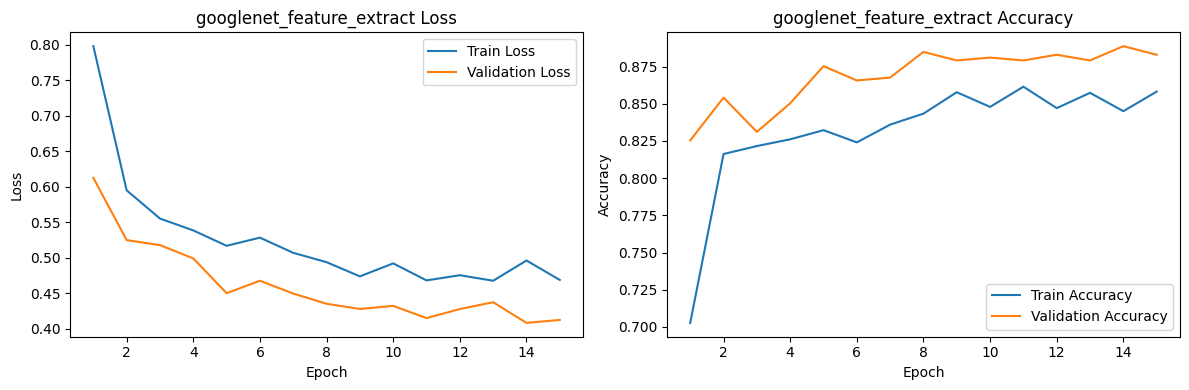


Training googlenet with strategy: fine_tune


/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Epoch 01/15 | Train Loss: 0.8531 | Train Acc: 0.8400 | Train F1: 0.8375 | Val Loss: 0.3804 | Val Acc: 0.9021 | Val F1: 0.9039
Epoch 02/15 | Train Loss: 0.6285 | Train Acc: 0.9120 | Train F1: 0.9130 | Val Loss: 0.3708 | Val Acc: 0.9136 | Val F1: 0.9155
Epoch 03/15 | Train Loss: 0.6083 | Train Acc: 0.9079 | Train F1: 0.9081 | Val Loss: 0.3596 | Val Acc: 0.9079 | Val F1: 0.9099
Epoch 04/15 | Train Loss: 0.5875 | Train Acc: 0.9165 | Train F1: 0.9164 | Val Loss: 0.3525 | Val Acc: 0.9155 | Val F1: 0.9173
Epoch 05/15 | Train Loss: 0.5552 | Train Acc: 0.9235 | Train F1: 0.9232 | Val Loss: 0.3601 | Val Acc: 0.9271 | Val F1: 0.9279
Epoch 06/15 | Train Loss: 0.5598 | Train Acc: 0.9272 | Train F1: 0.9276 | Val Loss: 0.3568 | Val Acc: 0.9271 | Val F1: 0.9279
Epoch 07/15 | Train Loss: 0.5232 | Train Acc: 0.9359 | Train F1: 0.9352 | Val Loss: 0.3953 | Val Acc: 0.9136 | Val F1: 0.9158
Epoch 08/15 | Train Loss: 0.4984 | Train Acc: 0.9441 | Train F1: 0.9444 | Val Loss: 0.3454 | Val Acc: 0.9347 | Val F1:

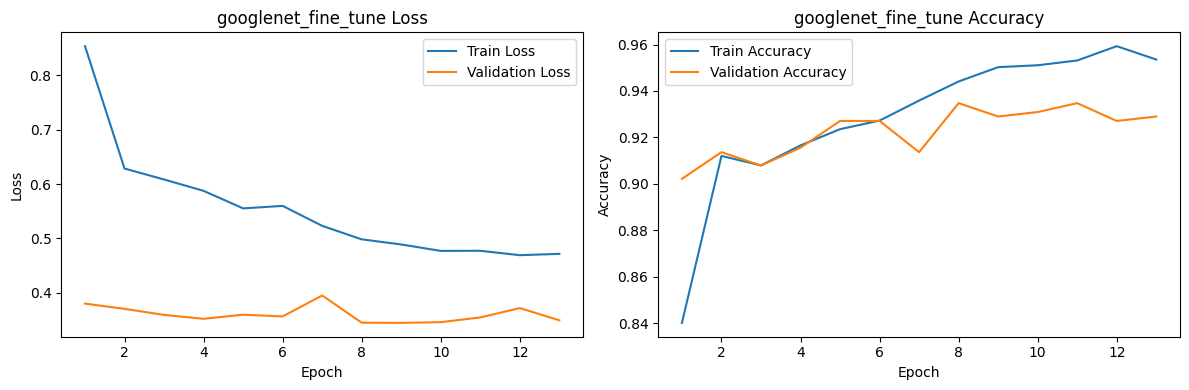


Training resnet18 with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


Epoch 01/15 | Train Loss: 0.8219 | Train Acc: 0.6698 | Train F1: 0.6645 | Val Loss: 0.5796 | Val Acc: 0.8273 | Val F1: 0.8290
Epoch 02/15 | Train Loss: 0.5871 | Train Acc: 0.8080 | Train F1: 0.8059 | Val Loss: 0.5395 | Val Acc: 0.8273 | Val F1: 0.8264
Epoch 03/15 | Train Loss: 0.5390 | Train Acc: 0.8322 | Train F1: 0.8277 | Val Loss: 0.4615 | Val Acc: 0.8676 | Val F1: 0.8684
Epoch 04/15 | Train Loss: 0.5298 | Train Acc: 0.8195 | Train F1: 0.8193 | Val Loss: 0.4746 | Val Acc: 0.8637 | Val F1: 0.8667
Epoch 05/15 | Train Loss: 0.5319 | Train Acc: 0.8240 | Train F1: 0.8225 | Val Loss: 0.4360 | Val Acc: 0.8714 | Val F1: 0.8726
Epoch 06/15 | Train Loss: 0.4927 | Train Acc: 0.8536 | Train F1: 0.8519 | Val Loss: 0.4314 | Val Acc: 0.8810 | Val F1: 0.8820
Epoch 07/15 | Train Loss: 0.5046 | Train Acc: 0.8355 | Train F1: 0.8343 | Val Loss: 0.4315 | Val Acc: 0.8772 | Val F1: 0.8793
Epoch 08/15 | Train Loss: 0.5060 | Train Acc: 0.8409 | Train F1: 0.8380 | Val Loss: 0.4239 | Val Acc: 0.8810 | Val F1:

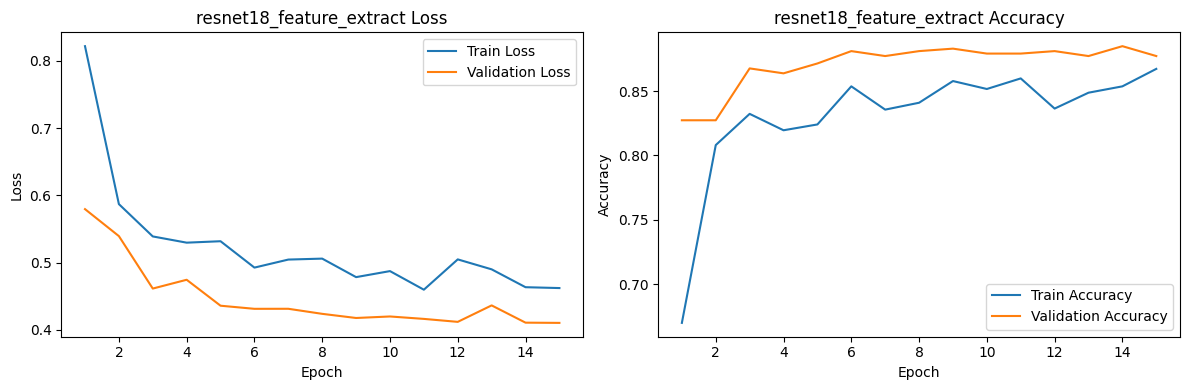


Training resnet18 with strategy: fine_tune
Epoch 01/15 | Train Loss: 0.4565 | Train Acc: 0.8618 | Train F1: 0.8612 | Val Loss: 0.4303 | Val Acc: 0.9021 | Val F1: 0.9029
Epoch 02/15 | Train Loss: 0.3636 | Train Acc: 0.9149 | Train F1: 0.9157 | Val Loss: 0.3789 | Val Acc: 0.9079 | Val F1: 0.9102
Epoch 03/15 | Train Loss: 0.3227 | Train Acc: 0.9326 | Train F1: 0.9323 | Val Loss: 0.3730 | Val Acc: 0.9175 | Val F1: 0.9193
Epoch 04/15 | Train Loss: 0.3064 | Train Acc: 0.9400 | Train F1: 0.9404 | Val Loss: 0.3330 | Val Acc: 0.9271 | Val F1: 0.9283
Epoch 05/15 | Train Loss: 0.2978 | Train Acc: 0.9437 | Train F1: 0.9434 | Val Loss: 0.3554 | Val Acc: 0.9175 | Val F1: 0.9194
Epoch 06/15 | Train Loss: 0.2896 | Train Acc: 0.9465 | Train F1: 0.9467 | Val Loss: 0.3406 | Val Acc: 0.9405 | Val F1: 0.9416
Epoch 07/15 | Train Loss: 0.2860 | Train Acc: 0.9490 | Train F1: 0.9491 | Val Loss: 0.3408 | Val Acc: 0.9309 | Val F1: 0.9321
Epoch 08/15 | Train Loss: 0.2554 | Train Acc: 0.9650 | Train F1: 0.9650 | 

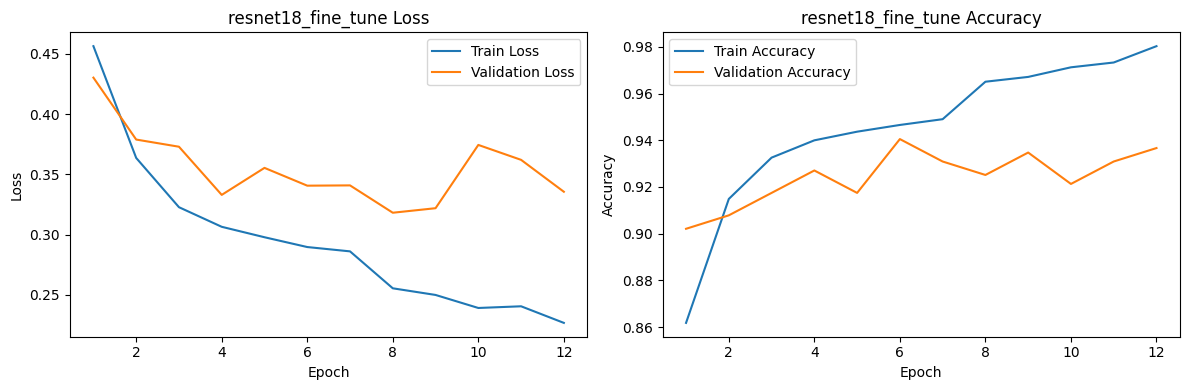


Training resnet18 with strategy: from_scratch
Epoch 01/15 | Train Loss: 0.6837 | Train Acc: 0.7504 | Train F1: 0.7490 | Val Loss: 0.5723 | Val Acc: 0.7965 | Val F1: 0.7870
Epoch 02/15 | Train Loss: 0.5363 | Train Acc: 0.8063 | Train F1: 0.8059 | Val Loss: 0.6830 | Val Acc: 0.7486 | Val F1: 0.7249
Epoch 03/15 | Train Loss: 0.5085 | Train Acc: 0.8347 | Train F1: 0.8334 | Val Loss: 1.1400 | Val Acc: 0.5470 | Val F1: 0.4797
Epoch 04/15 | Train Loss: 0.4791 | Train Acc: 0.8446 | Train F1: 0.8442 | Val Loss: 0.4191 | Val Acc: 0.8868 | Val F1: 0.8888
Epoch 05/15 | Train Loss: 0.4615 | Train Acc: 0.8520 | Train F1: 0.8529 | Val Loss: 0.4995 | Val Acc: 0.8407 | Val F1: 0.8428
Epoch 06/15 | Train Loss: 0.4463 | Train Acc: 0.8664 | Train F1: 0.8652 | Val Loss: 0.4338 | Val Acc: 0.8695 | Val F1: 0.8695
Epoch 07/15 | Train Loss: 0.4173 | Train Acc: 0.8808 | Train F1: 0.8801 | Val Loss: 0.4111 | Val Acc: 0.8772 | Val F1: 0.8788
Epoch 08/15 | Train Loss: 0.4218 | Train Acc: 0.8783 | Train F1: 0.8769

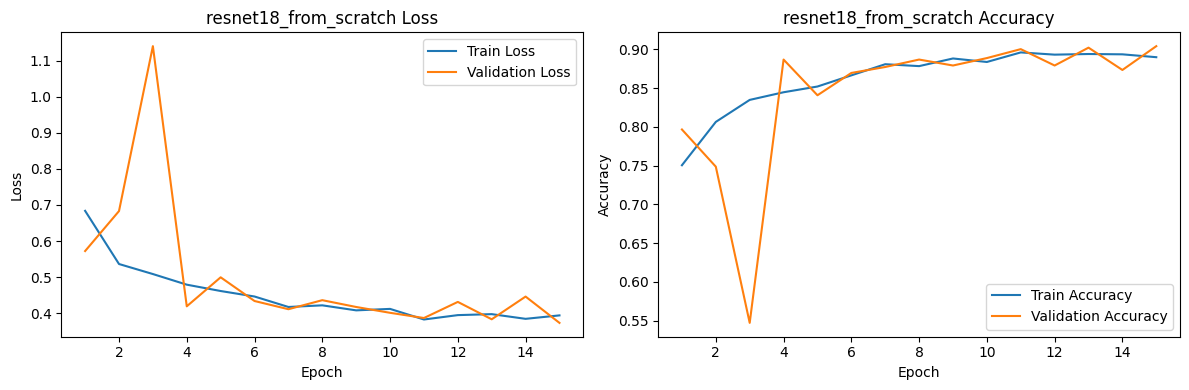


Training densenet121 with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 60.4MB/s]


Epoch 01/15 | Train Loss: 0.7755 | Train Acc: 0.6986 | Train F1: 0.6981 | Val Loss: 0.6202 | Val Acc: 0.7774 | Val F1: 0.7787
Epoch 02/15 | Train Loss: 0.5763 | Train Acc: 0.8228 | Train F1: 0.8199 | Val Loss: 0.5396 | Val Acc: 0.8234 | Val F1: 0.8264
Epoch 03/15 | Train Loss: 0.5268 | Train Acc: 0.8339 | Train F1: 0.8345 | Val Loss: 0.5255 | Val Acc: 0.8234 | Val F1: 0.8262
Epoch 04/15 | Train Loss: 0.4940 | Train Acc: 0.8475 | Train F1: 0.8463 | Val Loss: 0.4783 | Val Acc: 0.8522 | Val F1: 0.8540
Epoch 05/15 | Train Loss: 0.4764 | Train Acc: 0.8561 | Train F1: 0.8550 | Val Loss: 0.4698 | Val Acc: 0.8560 | Val F1: 0.8583
Epoch 06/15 | Train Loss: 0.4649 | Train Acc: 0.8590 | Train F1: 0.8607 | Val Loss: 0.4621 | Val Acc: 0.8503 | Val F1: 0.8527
Epoch 07/15 | Train Loss: 0.4543 | Train Acc: 0.8709 | Train F1: 0.8701 | Val Loss: 0.4511 | Val Acc: 0.8656 | Val F1: 0.8665
Epoch 08/15 | Train Loss: 0.4451 | Train Acc: 0.8709 | Train F1: 0.8698 | Val Loss: 0.4574 | Val Acc: 0.8599 | Val F1:

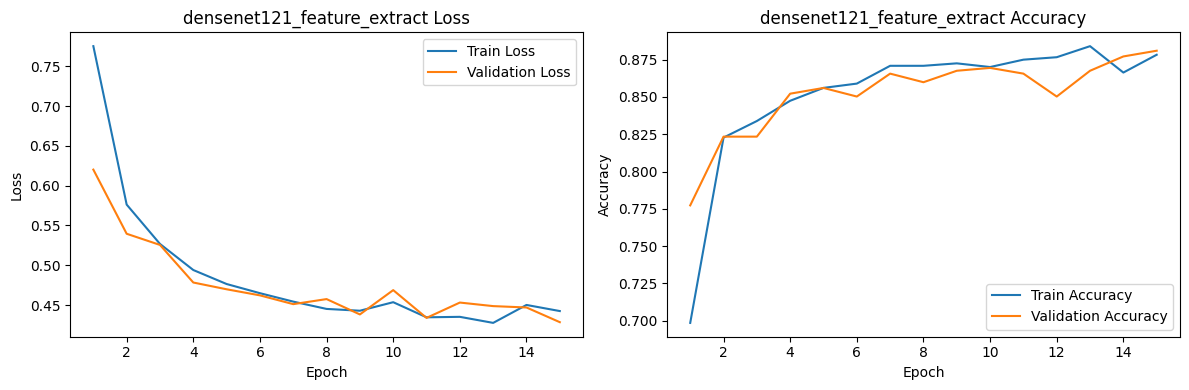


Training densenet121 with strategy: fine_tune
Epoch 01/15 | Train Loss: 0.4613 | Train Acc: 0.8627 | Train F1: 0.8609 | Val Loss: 0.3745 | Val Acc: 0.9098 | Val F1: 0.9111
Epoch 02/15 | Train Loss: 0.3595 | Train Acc: 0.9178 | Train F1: 0.9187 | Val Loss: 0.3560 | Val Acc: 0.9155 | Val F1: 0.9175
Epoch 03/15 | Train Loss: 0.3496 | Train Acc: 0.9215 | Train F1: 0.9200 | Val Loss: 0.3933 | Val Acc: 0.9136 | Val F1: 0.9146
Epoch 04/15 | Train Loss: 0.3166 | Train Acc: 0.9383 | Train F1: 0.9382 | Val Loss: 0.3729 | Val Acc: 0.9175 | Val F1: 0.9189
Epoch 05/15 | Train Loss: 0.3064 | Train Acc: 0.9400 | Train F1: 0.9390 | Val Loss: 0.3628 | Val Acc: 0.9232 | Val F1: 0.9249
Epoch 06/15 | Train Loss: 0.2840 | Train Acc: 0.9523 | Train F1: 0.9523 | Val Loss: 0.3797 | Val Acc: 0.9040 | Val F1: 0.9061
Early stopping triggered.


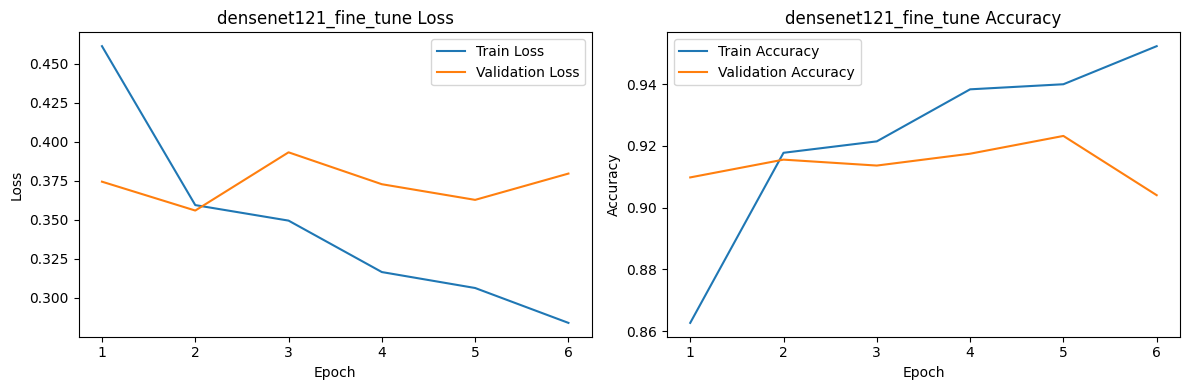


Training efficientnet_b0 with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 170MB/s]


Epoch 01/15 | Train Loss: 0.7029 | Train Acc: 0.7595 | Train F1: 0.7610 | Val Loss: 0.5062 | Val Acc: 0.8522 | Val F1: 0.8544
Epoch 02/15 | Train Loss: 0.4985 | Train Acc: 0.8532 | Train F1: 0.8514 | Val Loss: 0.4566 | Val Acc: 0.8656 | Val F1: 0.8673
Epoch 03/15 | Train Loss: 0.4639 | Train Acc: 0.8668 | Train F1: 0.8651 | Val Loss: 0.4332 | Val Acc: 0.8733 | Val F1: 0.8758
Epoch 04/15 | Train Loss: 0.4792 | Train Acc: 0.8507 | Train F1: 0.8484 | Val Loss: 0.4204 | Val Acc: 0.8791 | Val F1: 0.8814
Epoch 05/15 | Train Loss: 0.4826 | Train Acc: 0.8581 | Train F1: 0.8580 | Val Loss: 0.4171 | Val Acc: 0.8791 | Val F1: 0.8818
Epoch 06/15 | Train Loss: 0.4488 | Train Acc: 0.8680 | Train F1: 0.8663 | Val Loss: 0.4171 | Val Acc: 0.8810 | Val F1: 0.8834
Epoch 07/15 | Train Loss: 0.4486 | Train Acc: 0.8734 | Train F1: 0.8736 | Val Loss: 0.4189 | Val Acc: 0.8676 | Val F1: 0.8708
Epoch 08/15 | Train Loss: 0.4536 | Train Acc: 0.8627 | Train F1: 0.8617 | Val Loss: 0.4205 | Val Acc: 0.8791 | Val F1:

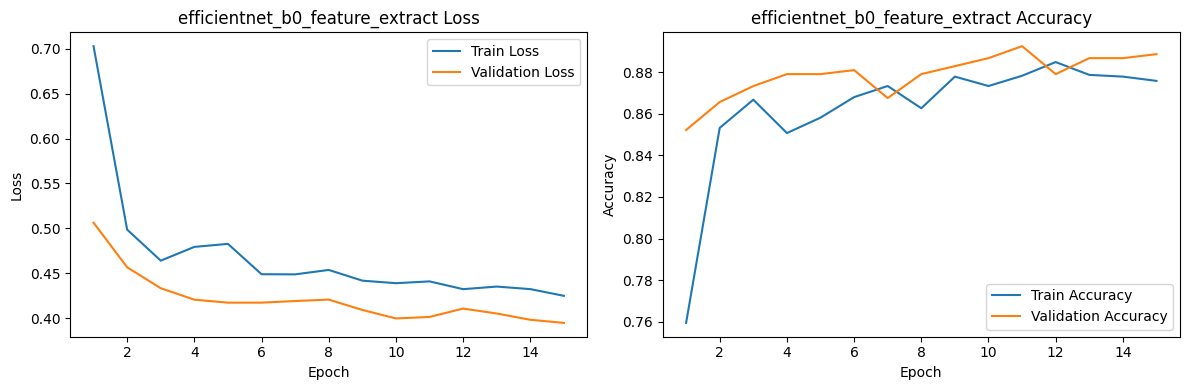


Training efficientnet_b0 with strategy: fine_tune
Epoch 01/15 | Train Loss: 0.4663 | Train Acc: 0.8725 | Train F1: 0.8725 | Val Loss: 0.3804 | Val Acc: 0.8944 | Val F1: 0.8971
Epoch 02/15 | Train Loss: 0.3586 | Train Acc: 0.9100 | Train F1: 0.9109 | Val Loss: 0.3408 | Val Acc: 0.9002 | Val F1: 0.9027
Epoch 03/15 | Train Loss: 0.3301 | Train Acc: 0.9268 | Train F1: 0.9268 | Val Loss: 0.3453 | Val Acc: 0.9213 | Val F1: 0.9228
Epoch 04/15 | Train Loss: 0.3018 | Train Acc: 0.9400 | Train F1: 0.9392 | Val Loss: 0.3261 | Val Acc: 0.9347 | Val F1: 0.9361
Epoch 05/15 | Train Loss: 0.2928 | Train Acc: 0.9461 | Train F1: 0.9469 | Val Loss: 0.3468 | Val Acc: 0.9271 | Val F1: 0.9285
Epoch 06/15 | Train Loss: 0.2812 | Train Acc: 0.9523 | Train F1: 0.9523 | Val Loss: 0.3302 | Val Acc: 0.9347 | Val F1: 0.9362
Epoch 07/15 | Train Loss: 0.2831 | Train Acc: 0.9502 | Train F1: 0.9508 | Val Loss: 0.3315 | Val Acc: 0.9367 | Val F1: 0.9380
Epoch 08/15 | Train Loss: 0.2627 | Train Acc: 0.9605 | Train F1: 0.

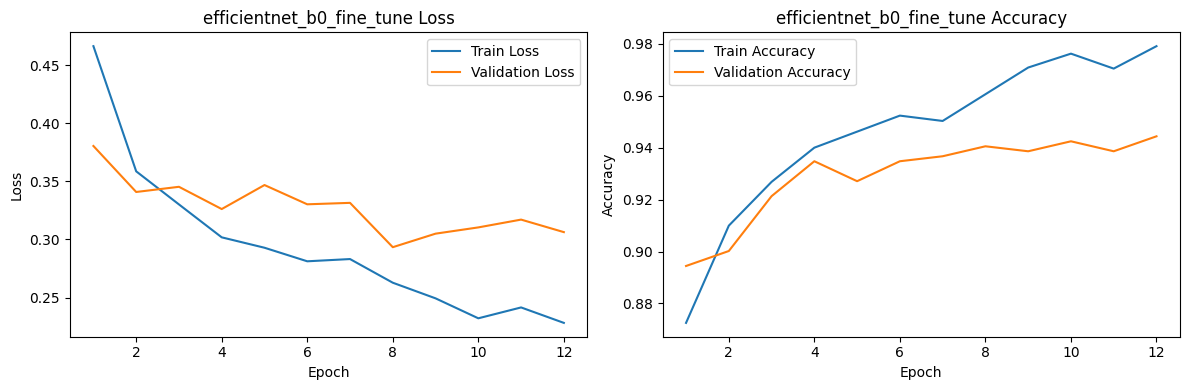


Training regnet_y_400mf with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/regnet_y_400mf-e6988f5f.pth" to /root/.cache/torch/hub/checkpoints/regnet_y_400mf-e6988f5f.pth


100%|██████████| 16.8M/16.8M [00:00<00:00, 18.1MB/s]


Epoch 01/15 | Train Loss: 0.9035 | Train Acc: 0.6234 | Train F1: 0.6232 | Val Loss: 0.7878 | Val Acc: 0.7486 | Val F1: 0.7446
Epoch 02/15 | Train Loss: 0.7222 | Train Acc: 0.7574 | Train F1: 0.7588 | Val Loss: 0.6729 | Val Acc: 0.7985 | Val F1: 0.7986
Epoch 03/15 | Train Loss: 0.6455 | Train Acc: 0.7956 | Train F1: 0.7944 | Val Loss: 0.6300 | Val Acc: 0.7927 | Val F1: 0.7942
Epoch 04/15 | Train Loss: 0.6088 | Train Acc: 0.8022 | Train F1: 0.7993 | Val Loss: 0.5957 | Val Acc: 0.8157 | Val F1: 0.8154
Epoch 05/15 | Train Loss: 0.5777 | Train Acc: 0.8228 | Train F1: 0.8219 | Val Loss: 0.5730 | Val Acc: 0.8100 | Val F1: 0.8100
Epoch 06/15 | Train Loss: 0.5740 | Train Acc: 0.8170 | Train F1: 0.8151 | Val Loss: 0.5482 | Val Acc: 0.8464 | Val F1: 0.8482
Epoch 07/15 | Train Loss: 0.5673 | Train Acc: 0.8092 | Train F1: 0.8072 | Val Loss: 0.5505 | Val Acc: 0.8177 | Val F1: 0.8193
Epoch 08/15 | Train Loss: 0.5583 | Train Acc: 0.8104 | Train F1: 0.8092 | Val Loss: 0.5431 | Val Acc: 0.8273 | Val F1:

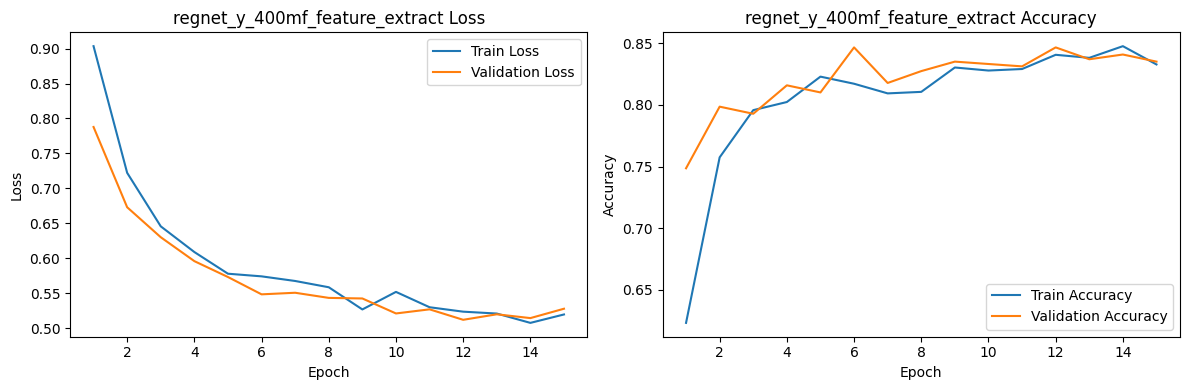


Training convnext_tiny with strategy: feature_extract
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 229MB/s] 


Epoch 01/15 | Train Loss: 0.5871 | Train Acc: 0.8035 | Train F1: 0.8007 | Val Loss: 0.4438 | Val Acc: 0.8733 | Val F1: 0.8743
Epoch 02/15 | Train Loss: 0.4454 | Train Acc: 0.8701 | Train F1: 0.8685 | Val Loss: 0.4078 | Val Acc: 0.8906 | Val F1: 0.8934
Epoch 03/15 | Train Loss: 0.4050 | Train Acc: 0.8898 | Train F1: 0.8878 | Val Loss: 0.3889 | Val Acc: 0.9040 | Val F1: 0.9062
Epoch 04/15 | Train Loss: 0.3988 | Train Acc: 0.8964 | Train F1: 0.8955 | Val Loss: 0.3806 | Val Acc: 0.9079 | Val F1: 0.9096
Epoch 05/15 | Train Loss: 0.3953 | Train Acc: 0.8935 | Train F1: 0.8931 | Val Loss: 0.3796 | Val Acc: 0.9021 | Val F1: 0.9041
Epoch 06/15 | Train Loss: 0.3981 | Train Acc: 0.8902 | Train F1: 0.8913 | Val Loss: 0.3832 | Val Acc: 0.9002 | Val F1: 0.9024
Epoch 07/15 | Train Loss: 0.3757 | Train Acc: 0.9021 | Train F1: 0.9009 | Val Loss: 0.3792 | Val Acc: 0.9060 | Val F1: 0.9078
Epoch 08/15 | Train Loss: 0.3768 | Train Acc: 0.9001 | Train F1: 0.9005 | Val Loss: 0.3755 | Val Acc: 0.9079 | Val F1:

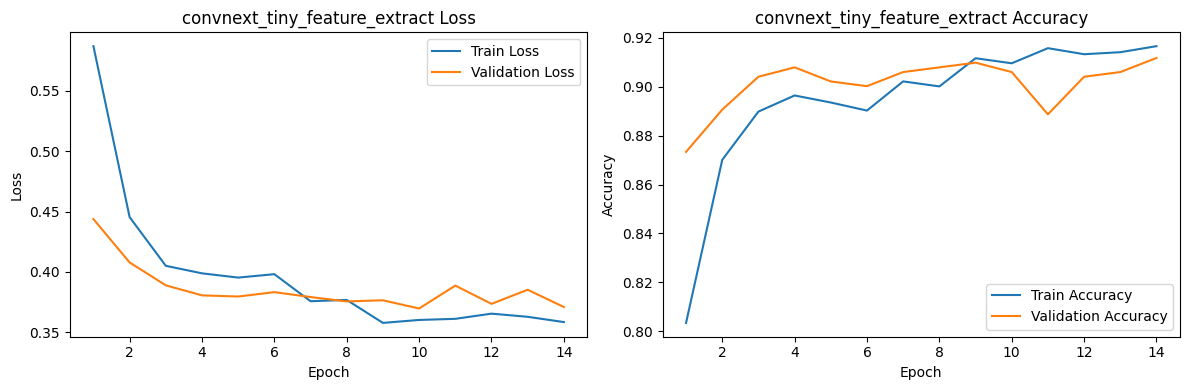

In [21]:
# train existing cnn models with multiple strategies
for model_name in selected_model_names:
    for strategy in selected_strategies[model_name]:
        print()
        print("=" * 80)
        print(f"Training {model_name} with strategy: {strategy}")
        print("=" * 80)

        model = create_model(model_name, strategy, num_classes=num_classes)
        criterion = get_criterion()
        optimizer = get_optimizer(model, strategy=strategy, model_name=model_name)
        scheduler = get_scheduler(optimizer)

        model, history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            model_name=model_name,
            strategy=strategy,
            num_epochs=num_epochs
        )

        experiment_name = f"{model_name}_{strategy}"
        trained_models[experiment_name] = model
        histories[experiment_name] = history

        val_metrics, _, _ = evaluate_model(model, val_loader, criterion)

        validation_results.append({
            "model": model_name,
            "strategy": strategy,
            "trainable_params": count_parameters(model),
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision_macro": val_metrics["precision_macro"],
            "val_recall_macro": val_metrics["recall_macro"],
            "val_f1_macro": val_metrics["f1_macro"]
        })

        plot_history(history, experiment_name)

In [22]:
#Show validation comparison
results_df = pd.DataFrame(validation_results)
results_df = results_df.sort_values(by=["val_f1_macro", "val_accuracy"], ascending=False).reset_index(drop=True)
results_df

,model,strategy,trainable_params,train_loss,train_accuracy,train_f1_macro,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro
0,efficientnet_b0,fine_tune,3159583,NaN,NaN,NaN,0.293319,0.940499,0.941686,0.941846,0.941761
1,alexnet,fine_tune,56021507,NaN,NaN,NaN,0.312555,0.934741,0.935597,0.936308,0.935932
2,alexnet,feature_extract,54546435,NaN,NaN,NaN,0.321450,0.932821,0.937470,0.932722,0.934149
3,googlenet,fine_tune,6665193,NaN,NaN,NaN,0.345002,0.928983,0.930456,0.930675,0.930502
4,vgg16,feature_extract,119558147,NaN,NaN,NaN,0.347635,0.927063,0.928317,0.929652,0.928351
5,resnet18,fine_tune,8395267,NaN,NaN,NaN,0.318133,0.925144,0.926638,0.927775,0.926683
6,densenet121,fine_tune,2163203,NaN,NaN,NaN,0.356003,0.915547,0.919465,0.916154,0.917509
7,convnext_tiny,feature_extract,3843,NaN,NaN,NaN,0.369658,0.905950,0.907501,0.907908,0.907700
8,resnet18,from_scratch,11178051,NaN,NaN,NaN,0.373186,0.904031,0.908132,0.907169,0.905801
9,original,from_scratch,306147,0.424015,0.881579,0.884002,0.419717,0.890595,0.894414,0.891416,0.892567


# 3. Model Evaluation

The strongest-performing model from the development stage is evaluated on the held-out test set using classification metrics and class-level performance analysis.

In [23]:
# select the best model from section 2 and evaluate on the test set

best_row = results_df.iloc[0]
best_model_name = f"{best_row['model']}_{best_row['strategy']}"
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)
print(best_row)

Best model selected: efficientnet_b0_fine_tune
model                  efficientnet_b0
strategy                     fine_tune
trainable_params               3159583
train_loss                         NaN
train_accuracy                     NaN
train_f1_macro                     NaN
val_loss                      0.293319
val_accuracy                  0.940499
val_precision_macro           0.941686
val_recall_macro              0.941846
val_f1_macro                  0.941761
Name: 0, dtype: object


In [24]:
# evaluate best model on test set

test_criterion = get_criterion()
test_metrics, y_true, y_pred = evaluate_model(best_model, test_loader, test_criterion)

print("Test Set Performance")
print(f"Loss:            {test_metrics['loss']:.4f}")
print(f"Accuracy:        {test_metrics['accuracy']:.4f}")
print(f"Macro Precision: {test_metrics['precision_macro']:.4f}")
print(f"Macro Recall:    {test_metrics['recall_macro']:.4f}")
print(f"Macro F1 Score:  {test_metrics['f1_macro']:.4f}")

Test Set Performance
Loss:            0.3064
Accuracy:        0.9330
Macro Precision: 0.9352
Macro Recall:    0.9337
Macro F1 Score:  0.9340


In [25]:
# detailed classification report

print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

              precision    recall  f1-score   support

      Normal     0.8923    0.9255    0.9086       188
     Opacity     0.9371    0.8817    0.9085       169
   Pneumonia     0.9762    0.9939    0.9850       165

    accuracy                         0.9330       522
   macro avg     0.9352    0.9337    0.9340       522
weighted avg     0.9333    0.9330    0.9327       522



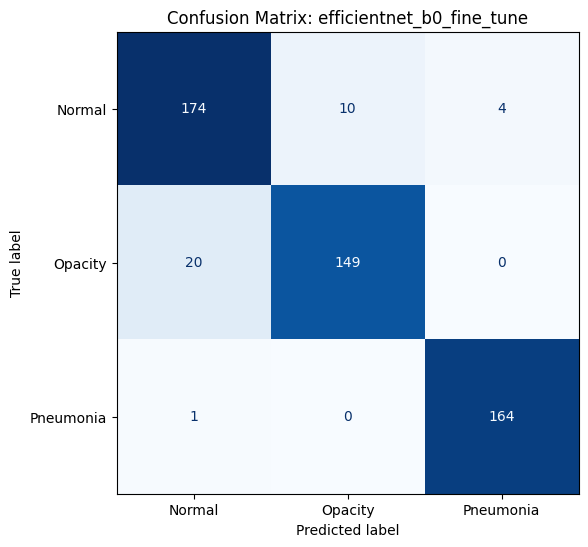

In [26]:
# confusion matrix

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

In [27]:
# optional final summary table

final_results_df = pd.DataFrame([
    {
        "best_model": best_model_name,
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"]
    }
])

final_results_df

,best_model,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,efficientnet_b0_fine_tune,0.306434,0.93295,0.935202,0.933709,0.934046
